In [ ]:
!pip install --quiet torch torchvision albumentations==1.3.0 opencv-python matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.5/123.5 kB 8.6 MB/s eta 0:00:00


In [ ]:
import os, cv2, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# 2) Kaggle download (run in Colab). Upload your kaggle.json when prompted.
from google.colab import files
files.upload()  # upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sasiprabhakr","key":"d034871ac0b3bfb8345c9c987875c3a9"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d andrewmvd/liver-tumor-segmentation \
    -p /content/datasets/ct --unzip

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/liver-tumor-segmentation
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
 99% 4.78G/4.84G [01:23<00:03, 17.7MB/s]
100% 4.84G/4.84G [01:23<00:00, 62.1MB/s]


In [ ]:
!pip install nibabel

In [ ]:
import os
import numpy as np
import nibabel as nib
import cv2
from torch.utils.data import Dataset
import torch # Added import for torch

class CTLiverDataset(Dataset):
    def __init__(self, root, img_size=256, max_patients=3):
        self.img_size = img_size
        self.images = []
        self.masks = []

        seg_dir = os.path.join(root, "segmentations")
        volume_dirs = sorted([d for d in os.listdir(root) if d.startswith("volume")])
        volume_dirs = volume_dirs[:max_patients]  # LIMIT patients

        print(f"Loading {len(volume_dirs)} CT patients...")

        for p_idx, vol_dir in enumerate(volume_dirs):
            vol_path = os.path.join(root, vol_dir)
            vol_files = sorted(os.listdir(vol_path))

            for vf in vol_files:
                if not vf.endswith(".nii"):
                    continue

                print(f"Patient {p_idx+1}: {vf}")

                img_vol = nib.load(os.path.join(vol_path, vf)).get_fdata()
                seg_name = vf.replace("volume", "segmentation")
                seg_path = os.path.join(seg_dir, seg_name)

                if not os.path.exists(seg_path):
                    continue

                mask_vol = nib.load(seg_path).get_fdata()

                for i in range(img_vol.shape[2]):
                    img = img_vol[:, :, i]
                    mask = mask_vol[:, :, i]

                    if np.sum(mask) > 0:  # skip empty slices
                        img = cv2.resize(img, (img_size, img_size))
                        mask = cv2.resize(mask, (img_size, img_size))

                        img = img / (np.max(img) + 1e-5)
                        mask = (mask > 0).astype(np.float32)

                        self.images.append(img)
                        self.masks.append(mask)

        print("CT dataset loading DONE.")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Convert NumPy arrays to torch.float32 tensors
        img = torch.tensor(self.images[idx], dtype=torch.float32).unsqueeze(0)
        mask = torch.tensor(self.masks[idx], dtype=torch.float32).unsqueeze(0)
        return img, mask


In [ ]:
ct_dataset = CTLiverDataset("/content/datasets/ct", max_patients=2)
print("CT dataset length:", len(ct_dataset))

Loading 2 CT patients...
Patient 1: volume-0.nii
Patient 1: volume-1.nii
Patient 1: volume-10.nii
Patient 1: volume-2.nii
Patient 1: volume-3.nii
Patient 1: volume-4.nii
Patient 1: volume-5.nii
Patient 1: volume-6.nii
Patient 1: volume-7.nii
Patient 1: volume-8.nii
Patient 1: volume-9.nii
Patient 2: volume-11.nii
Patient 2: volume-12.nii
Patient 2: volume-13.nii
Patient 2: volume-14.nii
Patient 2: volume-15.nii
Patient 2: volume-16.nii
Patient 2: volume-17.nii
Patient 2: volume-18.nii
Patient 2: volume-19.nii
Patient 2: volume-20.nii
CT dataset loading DONE.
CT dataset length: 3414


In [ ]:
from torch.utils.data import DataLoader

ct_loader = DataLoader(
    ct_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0
)

In [ ]:
imgs, masks = next(iter(ct_loader))
print(imgs.shape, masks.shape)

torch.Size([2, 1, 256, 256]) torch.Size([2, 1, 256, 256])


In [ ]:
from torch.utils.data import DataLoader

ct_loader = DataLoader(
    ct_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0
)

# sanity check
imgs, masks = next(iter(ct_loader))
print(imgs.shape, masks.shape)

torch.Size([2, 1, 256, 256]) torch.Size([2, 1, 256, 256])


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [ ]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(1, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.middle = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool1(d1))
        d3 = self.down3(self.pool2(d2))

        m = self.middle(self.pool3(d3))

        u3 = self.up3(m)
        u3 = self.conv3(torch.cat([u3, d3], dim=1))

        u2 = self.up2(u3)
        u2 = self.conv2(torch.cat([u2, d2], dim=1))

        u1 = self.up1(u2)
        u1 = self.conv1(torch.cat([u1, d1], dim=1))

        return self.out(u1)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = UNet().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Using device: cuda


In [ ]:
from torch.utils.data import DataLoader

# Safety check
assert ct_dataset is not None, "❌ ct_dataset is not created"

print("CT dataset size:", len(ct_dataset))

ct_loader = DataLoader(
    ct_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

# Final verification
imgs, masks = next(iter(ct_loader))
print("CT batch shapes:", imgs.shape, masks.shape)

# Assign loader for training
loader = ct_loader

CT dataset size: 3414
CT batch shapes: torch.Size([2, 1, 256, 256]) torch.Size([2, 1, 256, 256])


In [ ]:
EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    print(f"\nEpoch {epoch+1}/{EPOCHS} started")

    for batch_idx, (imgs, masks) in enumerate(loader):
        imgs = imgs.to(device)
        masks = masks.to(device)

        preds = model(imgs)
        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if batch_idx % 10 == 0:
            print(f"  Batch {batch_idx}, Loss: {loss.item():.4f}")

    print(f"Epoch {epoch+1} completed | Avg Loss: {total_loss/len(loader):.4f}")


Epoch 1/10 started
  Batch 0, Loss: 0.0067
  Batch 10, Loss: 0.0048
  Batch 20, Loss: 0.0164
  Batch 30, Loss: 0.0152
  Batch 40, Loss: 0.0234
  Batch 50, Loss: 0.0051
  Batch 60, Loss: 0.0190
  Batch 70, Loss: 0.0098
  Batch 80, Loss: 0.0060
  Batch 90, Loss: 0.0181
  Batch 100, Loss: 0.0108
  Batch 110, Loss: 0.0109
  Batch 120, Loss: 0.0079
  Batch 130, Loss: 0.0079
  Batch 140, Loss: 0.0085
  Batch 150, Loss: 0.0062
  Batch 160, Loss: 0.0066
  Batch 170, Loss: 0.0089
  Batch 180, Loss: 0.0038
  Batch 190, Loss: 0.0028
  Batch 200, Loss: 0.0095
  Batch 210, Loss: 0.0029
  Batch 220, Loss: 0.0103
  Batch 230, Loss: 0.0094
  Batch 240, Loss: 0.0091
  Batch 250, Loss: 0.0057
  Batch 260, Loss: 0.0025
  Batch 270, Loss: 0.0091
  Batch 280, Loss: 0.0112
  Batch 290, Loss: 0.0070
  Batch 300, Loss: 0.0116
  Batch 310, Loss: 0.0042
  Batch 320, Loss: 0.0178
  Batch 330, Loss: 0.0118
  Batch 340, Loss: 0.0169
  Batch 350, Loss: 0.0158
  Batch 360, Loss: 0.0083
  Batch 370, Loss: 0.0047
  B

/tmp/ipython-input-439/3943243674.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img = torch.tensor(img).unsqueeze(0).to(device)


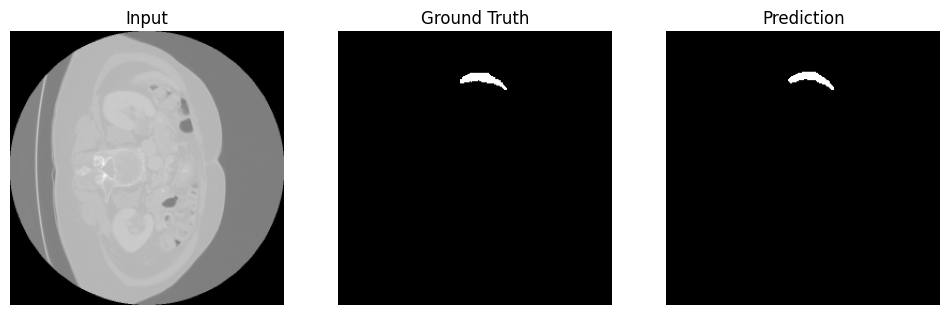

In [ ]:
model.eval()

with torch.no_grad():
    img, mask = loader.dataset[0]
    img = torch.tensor(img).unsqueeze(0).to(device)
    pred = torch.sigmoid(model(img))[0,0].cpu().numpy()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img[0,0].cpu(), cmap="gray")
plt.title("Input")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask[0], cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred > 0.5, cmap="gray")
plt.title("Prediction")
plt.axis("off")

plt.show()